# Introduction to Machine Learning: Unsupervised Learning

**Instructor:** Daniel Acuna, Ph.D.
**Position:** Associate Professor of Computer Science
**Institution:** University of Colorado Boulder

---

Lab 2: Principal Component Analysis (PCA)

---

In this lab, you will explore **Principal Component Analysis (PCA)**, one of the most
important dimensionality reduction techniques in machine learning. You will work with
the **Wine dataset**, which contains chemical measurements from 178 wine samples.

You will:
- Understand why standardization is critical before applying PCA
- Fit a PCA model and analyze variance explained by each component
- Use scree plots and cumulative variance to choose the number of components
- Interpret loadings to understand what each principal component represents
- Transform data to principal component space and visualize the results
- Reconstruct data from a reduced number of components

These concepts are fundamental to dimensionality reduction, data visualization,
and preprocessing for downstream machine learning tasks.

## Setup (do not edit)

In [1]:
import pathlib
from typing import Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

RANDOM_STATE: int = 42
np.random.seed(RANDOM_STATE)

_DATA_PATH = pathlib.Path("wine.csv")
if not _DATA_PATH.exists():
    raise FileNotFoundError(
        "wine.csv is missing from the lab directory. Please run the download "
        "script (w2_download_datasets.py) or ask the TA for assistance."
    )

## 1. Load the Dataset *(10 points)*

Load the Wine dataset from `wine.csv` into a pandas DataFrame.

The Wine dataset contains chemical measurements from wines produced by three
different Italian cultivars. Each row represents a wine sample, and each column
represents a chemical property (e.g., alcohol content, malic acid, color intensity).

Store the following in the required variables:
- **`q1_shape`**: A tuple containing the shape of the DataFrame `(n_samples, n_features)`
- **`q1_columns`**: A list of all column names (feature names)
- **`q1_n_features`**: An integer representing the number of features

In [2]:
# Grade Cell: Question 1
#
# Task: Load the Wine dataset and explore its structure
#
# Instructions:
# 1. Read the CSV file using pd.read_csv()
# 2. Store the shape as a tuple in q1_shape
# 3. Store the column names as a list in q1_columns
# 4. Store the number of features (columns) as an integer in q1_n_features

# your code here
df = pd.read_csv(_DATA_PATH)
q1_shape = df.shape
q1_columns = list(df.columns)
q1_n_features = len(df.columns)

In [3]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 1
assert isinstance(q1_shape, tuple), (
    "q1_shape must be a tuple. Use df.shape which returns (rows, cols)."
)
assert len(q1_shape) == 2, (
    "q1_shape should have 2 elements (n_samples, n_features). "
    "Make sure you're using .shape, not .shape[0]."
)
assert q1_shape[0] > 0 and q1_shape[1] > 0, (
    "Shape values must be positive. Is your CSV loading correctly?"
)
assert isinstance(q1_columns, list), (
    "q1_columns must be a list. Use df.columns.tolist() to convert."
)
assert len(q1_columns) == q1_shape[1], (
    "Number of columns in q1_columns should match q1_shape[1]."
)
assert isinstance(q1_n_features, int), (
    "q1_n_features must be an integer."
)
print(f"Dataset shape: {q1_shape}")
print(f"Number of features: {q1_n_features}")
print(f"Features: {q1_columns}")

Dataset shape: (178, 13)
Number of features: 13
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


## 2. Compute Summary Statistics *(10 points)*

Before applying PCA, it's important to understand the scale of each feature.
Features with vastly different scales will dominate PCA if we don't standardize.

Compute the **mean**, **standard deviation**, and **range** (max - min) for each feature.

Store the results as:
- **`q2_means`**: A dictionary mapping feature names to their mean values (rounded to 2 decimals)
- **`q2_stds`**: A dictionary mapping feature names to their standard deviation values (rounded to 2 decimals, use `ddof=0`)
- **`q2_max_range_feature`**: The name of the feature with the largest range (string)

In [4]:
# Grade Cell: Question 2
#
# Task: Compute summary statistics for each feature
#
# Instructions:
# 1. Calculate the mean of each column and round to 2 decimals
# 2. Calculate the standard deviation of each column (use ddof=0) and round to 2 decimals
# 3. Calculate the range (max - min) for each column
# 4. Find the feature with the largest range

# your code here
q2_means = df.mean().round(2).to_dict()
q2_stds = df.std(ddof=0).round(2).to_dict()
q2_max_range_feature = (df.max() - df.min()).idxmax()

In [5]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 2
assert isinstance(q2_means, dict), (
    "q2_means must be a dictionary mapping feature names to mean values."
)
assert isinstance(q2_stds, dict), (
    "q2_stds must be a dictionary mapping feature names to std values."
)
assert len(q2_means) == q1_n_features, (
    f"q2_means should have {q1_n_features} entries, one for each feature."
)
assert len(q2_stds) == q1_n_features, (
    f"q2_stds should have {q1_n_features} entries, one for each feature."
)
assert all(isinstance(v, float) for v in q2_means.values()), (
    "All mean values should be floats. Use round() to ensure this."
)
assert all(v > 0 for v in q2_stds.values()), (
    "Standard deviations must be positive. Check your calculation."
)
assert isinstance(q2_max_range_feature, str), (
    "q2_max_range_feature must be a string (the feature name)."
)
assert q2_max_range_feature in q1_columns, (
    "q2_max_range_feature must be one of the feature names."
)
print(f"Feature means: {q2_means}")
print(f"Feature stds: {q2_stds}")
print(f"Feature with largest range: {q2_max_range_feature}")

Feature means: {'alcohol': 13.0, 'malic_acid': 2.34, 'ash': 2.37, 'alcalinity_of_ash': 19.49, 'magnesium': 99.74, 'total_phenols': 2.3, 'flavanoids': 2.03, 'nonflavanoid_phenols': 0.36, 'proanthocyanins': 1.59, 'color_intensity': 5.06, 'hue': 0.96, 'od280/od315_of_diluted_wines': 2.61, 'proline': 746.89}
Feature stds: {'alcohol': 0.81, 'malic_acid': 1.11, 'ash': 0.27, 'alcalinity_of_ash': 3.33, 'magnesium': 14.24, 'total_phenols': 0.62, 'flavanoids': 1.0, 'nonflavanoid_phenols': 0.12, 'proanthocyanins': 0.57, 'color_intensity': 2.31, 'hue': 0.23, 'od280/od315_of_diluted_wines': 0.71, 'proline': 314.02}
Feature with largest range: proline


## 3. Standardize the Data *(10 points)*

As we saw in Question 2, features have vastly different scales (e.g., proline ranges
from ~280 to ~1680, while hue ranges from ~0.5 to ~1.7). Without standardization,
proline would dominate PCA because it has the largest variance.

Apply **z-score standardization** to the data:
$$z_j = \frac{x_j - \mu_j}{\sigma_j}$$

Use `sklearn.preprocessing.StandardScaler` to standardize all features.

Store the results as:
- **`q3_scaled_data`**: A numpy array of the standardized data
- **`q3_scaled_means`**: A numpy array of column means of the scaled data (should all be ~0)
- **`q3_scaled_stds`**: A numpy array of column stds of the scaled data (should all be ~1)

In [6]:
# Grade Cell: Question 3
#
# Task: Standardize the data using StandardScaler
#
# Instructions:
# 1. Create a StandardScaler instance
# 2. Fit and transform the data (df.values or df as input)
# 3. Compute the column means and stds of the scaled data to verify

# your code here
scaler = StandardScaler()
q3_scaled_data = scaler.fit_transform(df)
q3_scaled_means = q3_scaled_data.mean(axis=0)
q3_scaled_stds = q3_scaled_data.std(axis=0)

In [7]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 3
assert isinstance(q3_scaled_data, np.ndarray), (
    "q3_scaled_data must be a numpy array."
)
assert q3_scaled_data.shape == q1_shape, (
    f"Scaled data should have same shape as original: {q1_shape}."
)
assert isinstance(q3_scaled_means, np.ndarray), (
    "q3_scaled_means must be a numpy array."
)
assert isinstance(q3_scaled_stds, np.ndarray), (
    "q3_scaled_stds must be a numpy array."
)
# Check that all means are approximately 0
assert np.allclose(q3_scaled_means, 0, atol=0.01), (
    "After standardization, all feature means should be ~0. "
    "Did you use StandardScaler correctly?"
)
# Check that all stds are approximately 1
assert np.allclose(q3_scaled_stds, 1, atol=0.01), (
    "After standardization, all feature stds should be ~1. "
    "Did you use StandardScaler correctly?"
)
print(f"Scaled data shape: {q3_scaled_data.shape}")
print(f"Scaled means (should be ~0): {q3_scaled_means}")
print(f"Scaled stds (should be ~1): {q3_scaled_stds}")

Scaled data shape: (178, 13)
Scaled means (should be ~0): [-8.38280756e-16 -1.19754394e-16 -8.37033314e-16 -3.99181312e-17
 -3.99181312e-17  0.00000000e+00 -3.99181312e-16  3.59263181e-16
 -1.19754394e-16  2.49488320e-17  1.99590656e-16  3.19345050e-16
 -1.59672525e-16]
Scaled stds (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 4. Fit PCA Model *(10 points)*

Now we're ready to apply PCA to the standardized data. PCA will find the directions
(principal components) that capture the most variance in the data.

Fit a PCA model to the **standardized** data. Keep all components for now so we can
analyze how much variance each captures.

Store the results as:
- **`q4_pca`**: The fitted PCA object
- **`q4_n_components`**: The number of components in the fitted model (should equal n_features)
- **`q4_explained_variance_ratio`**: A numpy array of the variance ratio explained by each component

In [8]:
# Grade Cell: Question 4
#
# Task: Fit a PCA model to the standardized data
#
# Instructions:
# 1. Create a PCA instance (without specifying n_components to keep all)
# 2. Fit the PCA model to q3_scaled_data
# 3. Access the explained_variance_ratio_ attribute

# your code here
q4_pca = PCA()
q4_pca.fit(q3_scaled_data)
q4_n_components = q4_pca.n_components_
q4_explained_variance_ratio = q4_pca.explained_variance_ratio_

In [9]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 4
assert hasattr(q4_pca, "components_"), (
    "PCA model doesn't appear to be fitted. Did you call pca.fit()?"
)
assert isinstance(q4_n_components, int), (
    "q4_n_components must be an integer."
)
assert q4_n_components == q1_n_features, (
    f"With all components kept, n_components should equal n_features ({q1_n_features}). "
    "Did you fit PCA without specifying n_components?"
)
assert isinstance(q4_explained_variance_ratio, np.ndarray), (
    "q4_explained_variance_ratio must be a numpy array."
)
assert len(q4_explained_variance_ratio) == q4_n_components, (
    "explained_variance_ratio should have one entry per component."
)
assert np.isclose(q4_explained_variance_ratio.sum(), 1.0, atol=0.001), (
    "Explained variance ratios should sum to 1.0 (100% of variance). "
    "Check that you're using the standardized data."
)
print(f"Number of components: {q4_n_components}")
print(f"Variance explained by each component:")
for i, var in enumerate(q4_explained_variance_ratio):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")

Number of components: 13
Variance explained by each component:
  PC1: 0.3620 (36.20%)
  PC2: 0.1921 (19.21%)
  PC3: 0.1112 (11.12%)
  PC4: 0.0707 (7.07%)
  PC5: 0.0656 (6.56%)
  PC6: 0.0494 (4.94%)
  PC7: 0.0424 (4.24%)
  PC8: 0.0268 (2.68%)
  PC9: 0.0222 (2.22%)
  PC10: 0.0193 (1.93%)
  PC11: 0.0174 (1.74%)
  PC12: 0.0130 (1.30%)
  PC13: 0.0080 (0.80%)


## 5. Analyze Variance Explained *(10 points)*

A key step in PCA is understanding how much variance each component captures.
The **scree plot** shows individual variance explained, while the **cumulative**
variance plot helps determine how many components to keep.

Compute:
- **`q5_pve`**: A list of individual Proportion of Variance Explained (PVE) for each component, rounded to 3 decimals
- **`q5_cumulative_pve`**: A list of cumulative PVE, rounded to 3 decimals
- **`q5_pc1_pc2_total`**: The total variance explained by PC1 and PC2 combined (float, rounded to 3 decimals)

In [10]:
# Grade Cell: Question 5
#
# Task: Compute individual and cumulative variance explained
#
# Instructions:
# 1. Use q4_explained_variance_ratio to get individual PVE
# 2. Use np.cumsum() to compute cumulative PVE
# 3. Round values to 3 decimal places
# 4. Compute the sum of PC1 and PC2 variance

# your code here
q5_pve = [round(x, 3) for x in q4_explained_variance_ratio]
q5_cumulative_pve = [round(x, 3) for x in np.cumsum(q4_explained_variance_ratio)]
q5_pc1_pc2_total = round(q4_explained_variance_ratio[0] + q4_explained_variance_ratio[1], 3)

In [11]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 5
assert isinstance(q5_pve, list), (
    "q5_pve must be a list of floats."
)
assert isinstance(q5_cumulative_pve, list), (
    "q5_cumulative_pve must be a list of floats."
)
assert len(q5_pve) == q4_n_components, (
    f"q5_pve should have {q4_n_components} entries."
)
assert len(q5_cumulative_pve) == q4_n_components, (
    f"q5_cumulative_pve should have {q4_n_components} entries."
)
# PVE values should be decreasing
assert all(q5_pve[i] >= q5_pve[i+1] for i in range(len(q5_pve)-1)), (
    "PVE values should be in decreasing order (PC1 explains most, then PC2, etc.)."
)
# Cumulative should be increasing
assert all(q5_cumulative_pve[i] <= q5_cumulative_pve[i+1] for i in range(len(q5_cumulative_pve)-1)), (
    "Cumulative PVE should be increasing."
)
# Last cumulative value should be ~1.0
assert abs(q5_cumulative_pve[-1] - 1.0) < 0.01, (
    "Final cumulative PVE should be ~1.0 (all variance explained)."
)
assert isinstance(q5_pc1_pc2_total, float), (
    "q5_pc1_pc2_total must be a float."
)
print(f"Individual PVE: {q5_pve}")
print(f"Cumulative PVE: {q5_cumulative_pve}")
print(f"PC1 + PC2 explain {q5_pc1_pc2_total*100:.1f}% of total variance")

Individual PVE: [0.362, 0.192, 0.111, 0.071, 0.066, 0.049, 0.042, 0.027, 0.022, 0.019, 0.017, 0.013, 0.008]
Cumulative PVE: [0.362, 0.554, 0.665, 0.736, 0.802, 0.851, 0.893, 0.92, 0.942, 0.962, 0.979, 0.992, 1.0]
PC1 + PC2 explain 55.4% of total variance


## 6. Choose Number of Components *(10 points)*

How many components should we keep? Common approaches include:
1. **Variance threshold**: Keep enough components to explain a target amount (e.g., 80%) of variance
2. **Scree plot elbow**: Look for where variance drops off sharply

Find the **minimum number of components** needed to explain at least **80%** of the variance.

Store the results as:
- **`q6_threshold`**: The variance threshold we're using (0.8)
- **`q6_n_components_80`**: The minimum number of components to explain ≥80% variance (integer)
- **`q6_actual_variance`**: The actual variance explained by those components (float, rounded to 3 decimals)

In [12]:
# Grade Cell: Question 6
#
# Task: Find minimum components to explain 80% of variance
#
# Instructions:
# 1. Use the cumulative variance from Q5
# 2. Find the first index where cumulative variance >= 0.8
# 3. Remember: the number of components is index + 1

# your code here
q6_threshold = 0.8
q6_n_components_80 = int(np.argmax(np.cumsum(q4_explained_variance_ratio) >= q6_threshold) + 1)
q6_actual_variance = round(np.cumsum(q4_explained_variance_ratio)[q6_n_components_80 - 1], 3)

In [13]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 6
assert q6_threshold == 0.8, (
    "q6_threshold should be 0.8 (80% variance threshold)."
)
assert isinstance(q6_n_components_80, int), (
    "q6_n_components_80 must be an integer."
)
assert 1 <= q6_n_components_80 <= q4_n_components, (
    f"Number of components should be between 1 and {q4_n_components}."
)
assert isinstance(q6_actual_variance, float), (
    "q6_actual_variance must be a float."
)
assert q6_actual_variance >= q6_threshold, (
    f"Actual variance ({q6_actual_variance}) should be >= threshold ({q6_threshold}). "
    "Did you find the right number of components?"
)
# Check that one fewer component doesn't meet threshold
if q6_n_components_80 > 1:
    prev_variance = sum(q5_pve[:q6_n_components_80-1])
    assert prev_variance < q6_threshold, (
        "You might have selected more components than necessary. "
        "Find the MINIMUM number needed to reach 80%."
    )
print(f"Threshold: {q6_threshold*100:.0f}%")
print(f"Components needed: {q6_n_components_80}")
print(f"Actual variance explained: {q6_actual_variance*100:.1f}%")

Threshold: 80%
Components needed: 5
Actual variance explained: 80.2%


## 7. Examine Loadings *(10 points)*

**Loadings** tell us how each original feature contributes to each principal component.
By examining loadings, we can interpret what each PC represents.

For PC1 and PC2:
- Find the features with the **largest absolute loadings**
- These are the features that drive each component

Store the results as:
- **`q7_loadings`**: A numpy array of shape (n_components, n_features) containing all loadings
- **`q7_pc1_top_feature`**: The name of the feature with the largest absolute loading on PC1
- **`q7_pc2_top_feature`**: The name of the feature with the largest absolute loading on PC2
- **`q7_pc1_top_loading`**: The loading value of the top feature on PC1 (rounded to 3 decimals)

In [14]:
# Grade Cell: Question 7
#
# Task: Examine and interpret PCA loadings
#
# Instructions:
# 1. Access the loadings from pca.components_
# 2. For PC1 (index 0), find the feature with largest |loading|
# 3. For PC2 (index 1), find the feature with largest |loading|
# 4. Use q1_columns to get feature names

# your code here
q7_loadings = q4_pca.components_
q7_pc1_top_feature = q1_columns[np.argmax(np.abs(q7_loadings[0]))]
q7_pc2_top_feature = q1_columns[np.argmax(np.abs(q7_loadings[1]))]
q7_pc1_top_loading = round(q7_loadings[0][np.argmax(np.abs(q7_loadings[0]))], 3)

In [15]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 7
assert isinstance(q7_loadings, np.ndarray), (
    "q7_loadings must be a numpy array."
)
assert q7_loadings.shape == (q4_n_components, q1_n_features), (
    f"Loadings shape should be ({q4_n_components}, {q1_n_features})."
)
# Loadings should be unit vectors (rows have norm 1)
for i in range(min(3, q4_n_components)):
    row_norm = np.linalg.norm(q7_loadings[i, :])
    assert np.isclose(row_norm, 1.0, atol=0.01), (
        f"Row {i} of loadings should have norm 1.0 (unit vector), got {row_norm:.3f}."
    )
assert isinstance(q7_pc1_top_feature, str), (
    "q7_pc1_top_feature must be a string (feature name)."
)
assert q7_pc1_top_feature in q1_columns, (
    "q7_pc1_top_feature must be one of the original feature names."
)
assert isinstance(q7_pc2_top_feature, str), (
    "q7_pc2_top_feature must be a string (feature name)."
)
assert q7_pc2_top_feature in q1_columns, (
    "q7_pc2_top_feature must be one of the original feature names."
)
assert isinstance(q7_pc1_top_loading, float), (
    "q7_pc1_top_loading must be a float."
)
assert -1 <= q7_pc1_top_loading <= 1, (
    "Loadings should be between -1 and 1."
)
print(f"Loadings shape: {q7_loadings.shape}")
print(f"PC1 top feature: {q7_pc1_top_feature} (loading: {q7_pc1_top_loading})")
print(f"PC2 top feature: {q7_pc2_top_feature}")

Loadings shape: (13, 13)
PC1 top feature: flavanoids (loading: 0.423)
PC2 top feature: color_intensity


## 8. Transform Data to PC Space *(10 points)*

Now let's transform the standardized data to principal component space. This gives us
the **scores** - the coordinates of each observation in the new PC coordinate system.

Transform the data and store in a DataFrame for easier analysis.

Store the results as:
- **`q8_scores`**: A numpy array of shape (n_samples, n_components) with the transformed data
- **`q8_scores_df`**: A pandas DataFrame with the scores, with columns named "PC1", "PC2", etc.
- **`q8_pc1_range`**: A tuple (min, max) of PC1 scores (values rounded to 2 decimals)

In [16]:
# Grade Cell: Question 8
#
# Task: Transform data to principal component space
#
# Instructions:
# 1. Use pca.transform() on the standardized data
# 2. Create a DataFrame with column names "PC1", "PC2", etc.
# 3. Find the range (min, max) of PC1 scores

# your code here
q8_scores = q4_pca.transform(q3_scaled_data)
q8_scores_df = pd.DataFrame(q8_scores, columns=[f"PC{i+1}" for i in range(q4_n_components)])
q8_pc1_range = (round(q8_scores[:, 0].min(), 2), round(q8_scores[:, 0].max(), 2))

In [17]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 8
assert isinstance(q8_scores, np.ndarray), (
    "q8_scores must be a numpy array."
)
assert q8_scores.shape == (q1_shape[0], q4_n_components), (
    f"Scores shape should be ({q1_shape[0]}, {q4_n_components})."
)
assert isinstance(q8_scores_df, pd.DataFrame), (
    "q8_scores_df must be a pandas DataFrame."
)
assert q8_scores_df.shape == q8_scores.shape, (
    "DataFrame should have same shape as scores array."
)
assert "PC1" in q8_scores_df.columns, (
    "DataFrame columns should be named 'PC1', 'PC2', etc."
)
assert "PC2" in q8_scores_df.columns, (
    "DataFrame columns should be named 'PC1', 'PC2', etc."
)
assert isinstance(q8_pc1_range, tuple), (
    "q8_pc1_range must be a tuple (min, max)."
)
assert len(q8_pc1_range) == 2, (
    "q8_pc1_range should have exactly 2 elements (min, max)."
)
assert q8_pc1_range[0] < q8_pc1_range[1], (
    "First element should be min, second should be max."
)
print(f"Scores shape: {q8_scores.shape}")
print(f"DataFrame columns: {list(q8_scores_df.columns[:5])}...")
print(f"PC1 range: {q8_pc1_range}")

Scores shape: (178, 13)
DataFrame columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']...
PC1 range: (-4.28, 4.31)


## 9. Visualize PCA Results *(10 points)*

One of PCA's most powerful uses is **visualization**. By plotting PC1 vs PC2, we can
see structure in high-dimensional data that would otherwise be invisible.

Create a function to plot PC1 vs PC2 scores, and identify observations that are
outliers (far from the center in PC space).

Store the results as:
- **`q9_plot_created`**: Set to True after creating the scatter plot
- **`q9_pc1_pc2_corr`**: The correlation between PC1 and PC2 scores (should be ~0 since PCs are orthogonal)
- **`q9_furthest_from_origin`**: Index of the sample furthest from origin in PC1-PC2 space

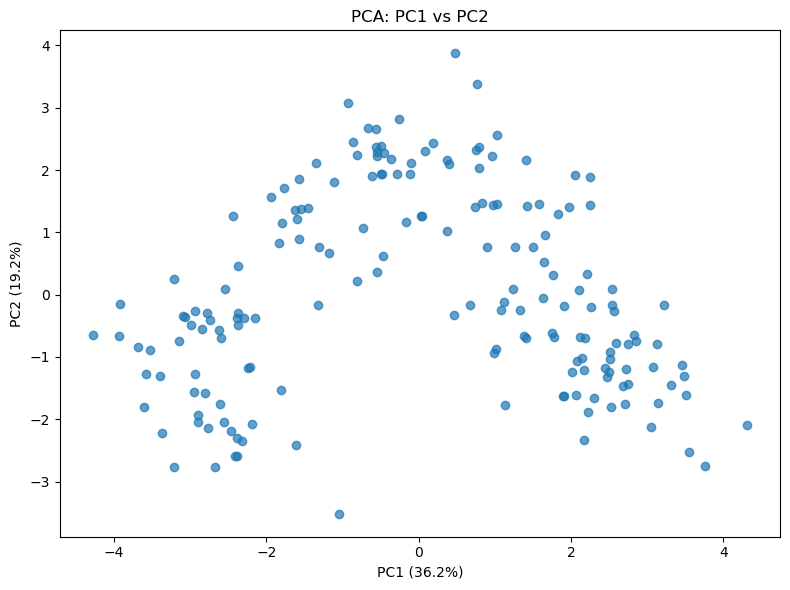

In [18]:
# Grade Cell: Question 9
#
# Task: Visualize PCA results and identify outliers
#
# Instructions:
# 1. Create a scatter plot of PC1 vs PC2
# 2. Calculate correlation between PC1 and PC2 scores
# 3. Find the sample furthest from origin (largest sqrt(PC1^2 + PC2^2))

# your code here
plt.figure(figsize=(8, 6))
plt.scatter(q8_scores[:, 0], q8_scores[:, 1], alpha=0.7)
plt.xlabel("PC1 (36.2%)")
plt.ylabel("PC2 (19.2%)")
plt.title("PCA: PC1 vs PC2")
plt.tight_layout()
plt.savefig("q9_pca_plot.png")
plt.show()
q9_plot_created = True

q9_pc1_pc2_corr = round(np.corrcoef(q8_scores[:, 0], q8_scores[:, 1])[0, 1], 5)
q9_furthest_from_origin = int(np.argmax(np.sqrt(q8_scores[:, 0]**2 + q8_scores[:, 1]**2)))

In [19]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 9
assert q9_plot_created is True, (
    "Set q9_plot_created to True after creating the scatter plot."
)
assert isinstance(q9_pc1_pc2_corr, float), (
    "q9_pc1_pc2_corr must be a float."
)
assert -0.1 <= q9_pc1_pc2_corr <= 0.1, (
    f"PC1 and PC2 should be uncorrelated (r ~ 0), got {q9_pc1_pc2_corr}. "
    "Principal components are orthogonal by construction."
)
assert isinstance(q9_furthest_from_origin, int), (
    "q9_furthest_from_origin must be an integer (sample index)."
)
assert 0 <= q9_furthest_from_origin < q1_shape[0], (
    f"Index should be between 0 and {q1_shape[0]-1}."
)
print(f"Plot created: {q9_plot_created}")
print(f"Correlation between PC1 and PC2: {q9_pc1_pc2_corr}")
print(f"Sample furthest from origin: index {q9_furthest_from_origin}")

Plot created: True
Correlation between PC1 and PC2: 0.0
Sample furthest from origin: index 14


## 10. PCA for Reconstruction *(10 points)*

A key property of PCA is that we can **reconstruct** the original data from
the principal components. Using fewer components gives an approximation.

The reconstruction error tells us how much information is lost when we reduce
dimensionality.

Implement a function to:
1. Transform data to PC space using only `k` components
2. Reconstruct (inverse transform) back to original feature space
3. Compute the Mean Squared Error (MSE) between original and reconstructed data

Store the results as:
- **`q10_reconstruction_error`**: A function that takes k and returns MSE (rounded to 4 decimals)
- **`q10_mse_all_components`**: MSE when using all components (should be ~0)
- **`q10_mse_2_components`**: MSE when using only 2 components
- **`q10_mse_5_components`**: MSE when using 5 components (our 80% threshold)

In [20]:
# Grade Cell: Question 10
#
# Task: Implement PCA reconstruction and compute reconstruction error
#
# Instructions:
# 1. Create a function that fits PCA with k components and computes reconstruction MSE
# 2. MSE = mean((original - reconstructed)^2)
# 3. Compute MSE for all components, 2 components, and 5 components

# your code here
def q10_reconstruction_error(k):
    pca_k = PCA(n_components=k)
    scores_k = pca_k.fit_transform(q3_scaled_data)
    reconstructed = pca_k.inverse_transform(scores_k)
    mse = np.mean((q3_scaled_data - reconstructed) ** 2)
    return round(mse, 4)

q10_mse_all_components = q10_reconstruction_error(13)
q10_mse_2_components = q10_reconstruction_error(2)
q10_mse_5_components = q10_reconstruction_error(5)

In [21]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 10
assert callable(q10_reconstruction_error), (
    "q10_reconstruction_error should be a function."
)
# Test the function
test_mse = q10_reconstruction_error(3)
assert isinstance(test_mse, float), (
    "Function should return a float."
)
assert test_mse >= 0, (
    "MSE must be non-negative."
)

assert isinstance(q10_mse_all_components, float), (
    "q10_mse_all_components must be a float."
)
assert q10_mse_all_components < 0.0001, (
    "MSE with all components should be ~0 (perfect reconstruction). "
    f"Got {q10_mse_all_components}."
)
assert isinstance(q10_mse_2_components, float), (
    "q10_mse_2_components must be a float."
)
assert isinstance(q10_mse_5_components, float), (
    "q10_mse_5_components must be a float."
)
# More components should give lower MSE
assert q10_mse_2_components > q10_mse_5_components, (
    "MSE with 2 components should be higher than with 5 components. "
    "More components = better reconstruction."
)
assert q10_mse_5_components > q10_mse_all_components, (
    "MSE with 5 components should be higher than with all components."
)
print(f"Reconstruction MSE with all components: {q10_mse_all_components}")
print(f"Reconstruction MSE with 2 components: {q10_mse_2_components}")
print(f"Reconstruction MSE with 5 components: {q10_mse_5_components}")

Reconstruction MSE with all components: 0.0
Reconstruction MSE with 2 components: 0.4459
Reconstruction MSE with 5 components: 0.1984


## Next Steps

Congratulations on completing the assignment! Before submitting:

1. Make sure all your cells run without errors.
2. Ensure you've answered all parts of each question.
3. If any autograder tests fail, revisit your answers.

**Key Takeaways from This Lab:**

- **Standardization is essential** before PCA when features have different scales
- **Variance explained** tells us how much information each PC captures
- **Scree plots and cumulative variance** help choose the number of components
- **Loadings** reveal which features drive each principal component
- **Scores** are the observations' coordinates in the new PC space
- **Reconstruction error** quantifies information loss from dimensionality reduction

In the next week, you'll learn about **clustering algorithms** that can work
in the reduced PC space to discover groups in your data!